# 1. Data Import

As always, we begin by importing the necessary libraries, loading the dataset for analysis, and displaying the first few rows to better understand what's in the dataset.

We'll be importing the CSVs exported raw from the Samsung Health app:
- Dates of menstruation (`cycle_flow_march_09.csv`)
- Daily vitality scores (`vitality_score_march_09.csv`)
- Basal Body Temperature (BBT) changes (`cycle_daily_temperature_changes_march_09.csv`)


In [24]:
import pandas as pd

# Get Period Dates
PERIOD_PATH = "raw-data/cycle_flow_march_09.csv"

period_df = pd.read_csv(PERIOD_PATH, skiprows=1, index_col=False)

# Convert 'start_time' to datetime
period_df['start_time'] = pd.to_datetime(period_df['start_time'])

# Sort dates just in case
period_df = period_df.sort_values(by='start_time')

# Calculate the difference between consecutive dates
period_df['diff'] = period_df['start_time'].diff().dt.days

# The first day of a cycle is where the difference is not 1 day
first_days = period_df.loc[period_df['diff'] != 1, 'start_time'].reset_index(drop=True)

In [25]:
# Import vitality scores
VITALITY_PATH = "raw-data/vitality_score_march_09.csv"

vitality_df = pd.read_csv(VITALITY_PATH, skiprows=1, index_col=False)

# Convert 'day_time' to datetime type
vitality_df['day_time'] = pd.to_datetime(vitality_df['day_time'])

# Check the columns of interest
vitality_df[
    [
        "day_time", # <- the "absolute" date of the vitality score (not timezone aware)
        "shr_value", # <- the average shown in the app
        "shrv_value", # <- the average shown in the app
        "sleep_duration" # in milliseconds
    ]
].tail()


,day_time,shr_value,shrv_value,sleep_duration
77,2025-03-05,64.870550,40.826360,26001428
78,2025-03-06,71.455950,34.428800,28320000
79,2025-03-07,66.410890,41.001750,27467142
80,2025-03-08,66.483765,44.317375,26682857
81,2025-03-09,68.430660,41.548447,25097142


In [26]:
# Get BBT
BBT_PATH = "raw-data/cycle_daily_temperature_changes_march_09.csv"

bbt_df = pd.read_csv(BBT_PATH, skiprows=1, index_col=False)
bbt_df['day_time'] = pd.to_datetime(bbt_df['day_time'])

# Only get days with BBT data
filtered_bbt_df = bbt_df[(bbt_df["temperature"] > 0) & (bbt_df['day_time'] > pd.to_datetime("2024-08-09"))] 

filtered_bbt_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 1 to 236
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   custom             208 non-null    object        
 1   discard_type       0 non-null      object        
 2   temperature_delta  208 non-null    float64       
 3   update_time        208 non-null    object        
 4   create_time        208 non-null    object        
 5   temperature        208 non-null    float64       
 6   extract_algo       208 non-null    float64       
 7   deviceuuid         208 non-null    object        
 8   pkg_name           208 non-null    object        
 9   datauuid           208 non-null    object        
 10  day_time           208 non-null    datetime64[ns]
 11  excluded           0 non-null      float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 21.1+ KB


# 2. Data Exploration

Next, we will visualize the data to see if it makes sense. For our variables of interest—sleeping heart rate (HR) and heart rate variability (HRV) should reflect cyclical patterns: Lower HR and higher HRV in the follicular phase, higher HR and lower HRV in the luteal phase.

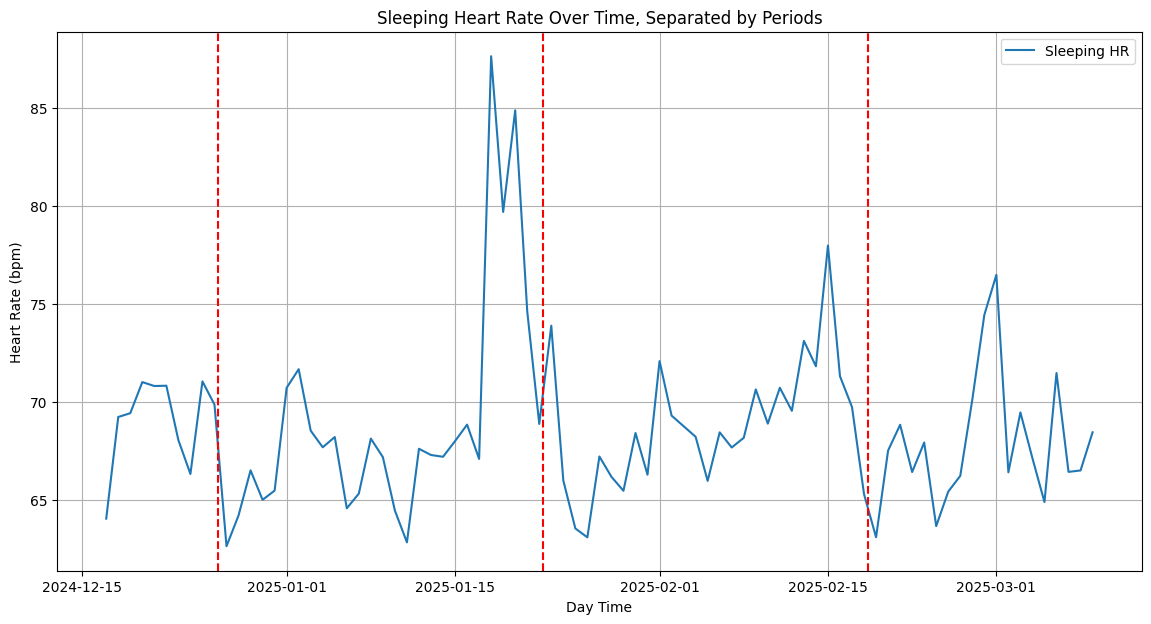

In [27]:
import matplotlib.pyplot as plt

# Plot Sleeping HR
plt.figure(figsize=(14, 7))
plt.plot(vitality_df['day_time'], vitality_df['shr_value'], label='Sleeping HR')
plt.xlabel('Day Time')
plt.ylabel('Heart Rate (bpm)')
plt.title('Sleeping Heart Rate Over Time, Separated by Periods')

# Mark First Day of Period
for day in first_days:
    if vitality_df['day_time'].min() <= day <= vitality_df['day_time'].max():
        plt.axvline(x=day, color='r', linestyle='--', label='First Day of Period' if day == first_days.iloc[0] else "")

plt.legend()
plt.grid(True)

plt.show()

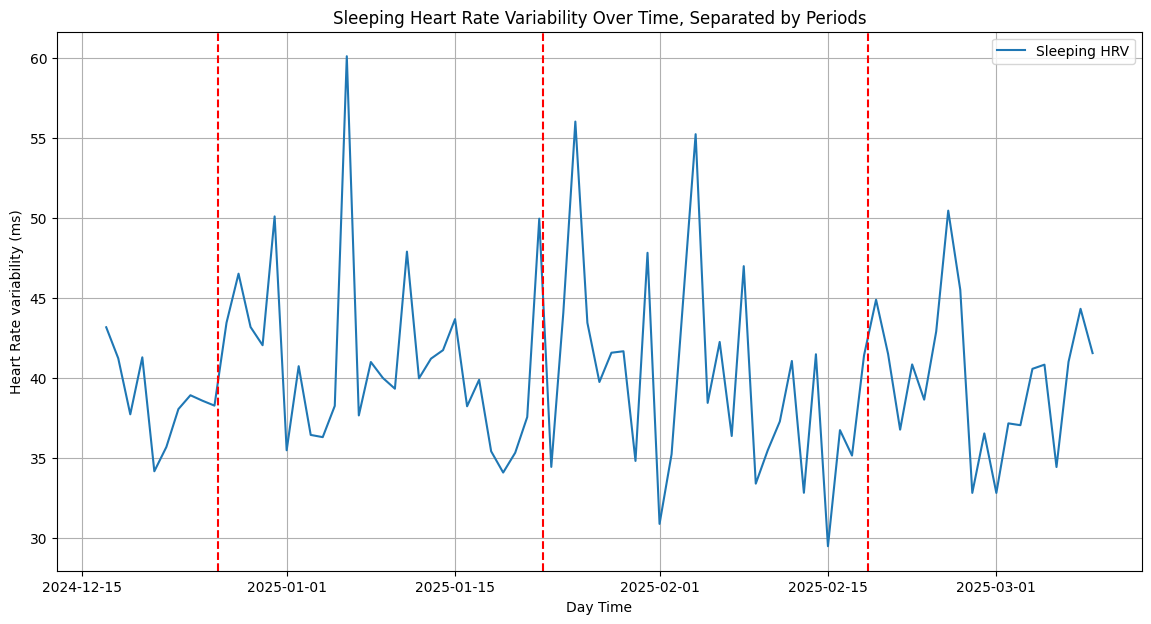

In [28]:
# Sleeping HRV
# Plot the data
plt.figure(figsize=(14, 7))
plt.plot(vitality_df['day_time'], vitality_df['shrv_value'], label='Sleeping HRV')
plt.xlabel('Day Time')
plt.ylabel('Heart Rate variability (ms)')
plt.title('Sleeping Heart Rate Variability Over Time, Separated by Periods')

# Mark First Day of Period
for day in first_days:
    if vitality_df['day_time'].min() <= day <= vitality_df['day_time'].max():
        plt.axvline(x=day, color='r', linestyle='--', label='First Day of Period' if day == first_days.iloc[0] else "")
        
plt.legend()
plt.grid(True)

        
plt.show()

# 3. Feature Engineering (Menstrual Phase)

In order to determine the menstrual phases, I need to know the date of ovulation. However, ovulation dates are not included in the raw data, so I would need to reverse engineer them from BBT data.

Ovulation can be detected through several physiological measures; the two most accessible ones are cervical mucus color and texture and BBT readings (and I only have data for the latter). 

After ovulation, the released egg cell transforms into the corpus luteum, which starts producing progesterone. The rise in progesterone typically contributes to a rise in basal body temperature that persists until the next menstruation.

In [29]:
# Calculate Menstrual Phase
# Step 1: Find points where BBT increases by at least 0.2°C
filtered_bbt_df.loc[:, "rise_detected"] = filtered_bbt_df["temperature_delta"] >= 0.2

# Step 2: Compute rolling baseline temperature before the rise (4-day average before each day)
filtered_bbt_df.loc[:, "baseline_BBT"] = (
    filtered_bbt_df["temperature"].shift(1).rolling(window=4, min_periods=3).mean()
)

# Step 3: Check if BBT stays elevated after the rise for at least 3 consecutive days
filtered_bbt_df.loc[:, "sustained_luteal"] = (
    filtered_bbt_df["temperature"].rolling(window=3, min_periods=3).mean()
    >= filtered_bbt_df["baseline_BBT"] + 0.2
)

# Step 4: Detect ovulation (first day of sustained increase)
filtered_bbt_df.loc[:, "ovulation"] = filtered_bbt_df["sustained_luteal"] & ~filtered_bbt_df[
    "sustained_luteal"
].shift(1, fill_value=False)

# Step 5: We likely have multiple candidate ovulation dates, so we need to filter them
filtered_bbt_df.loc[:, "cycle_start"] = filtered_bbt_df["day_time"].apply(
    lambda x: first_days[first_days <= x].max()
)

# Step 6: Find the latest ovulation date within each cycle
latest_ovulation_per_cycle = (
    filtered_bbt_df[filtered_bbt_df["ovulation"] == True]
    .groupby("cycle_start")["day_time"]
    .max()
)

# Step 7: Keep only the latest ovulation per cycle and adjust by -2 days
filtered_bbt_df.loc[:, "ovulation"] = filtered_bbt_df["day_time"].isin(latest_ovulation_per_cycle - pd.Timedelta(days=2))


/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_59796/1464647766.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df.loc[:, "rise_detected"] = filtered_bbt_df["temperature_delta"] >= 0.2
/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_59796/1464647766.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df.loc[:, "baseline_BBT"] = (
/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_59796/1464647766.py:11: SettingWithCopyWarning: 
A value is trying t

We'll visualize the approximated ovulation dates as a sanity check. As you might notice, our algorithm was not successful in detecting ovulation for one cycle (October 2024).

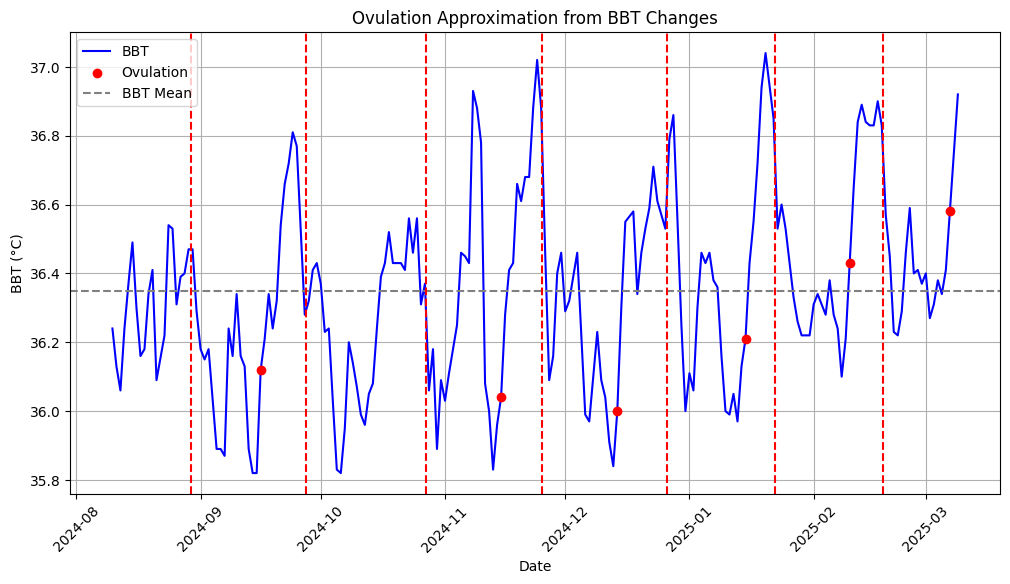

In [30]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(
    filtered_bbt_df["day_time"],
    filtered_bbt_df["temperature"],
    label="BBT",
    color="blue",
)
plt.scatter(
    filtered_bbt_df["day_time"][filtered_bbt_df["ovulation"]],
    filtered_bbt_df["temperature"][filtered_bbt_df["ovulation"]],
    color="red",
    label="Ovulation",
    zorder=3,
)
plt.axhline(
    filtered_bbt_df["temperature"].mean(),
    linestyle="--",
    color="gray",
    label="BBT Mean",
)

plt.xlabel("Date")
plt.ylabel("BBT (°C)")
plt.title("Ovulation Approximation from BBT Changes")
plt.xticks(rotation=45)
plt.grid()

# Mark First Day of Period
for day in first_days:
    if filtered_bbt_df["day_time"].min() <= day <= filtered_bbt_df["day_time"].max():
        plt.axvline(
            x=day,
            color="r",
            linestyle="--",
            label="First Day of Period" if day == first_days.iloc[0] else "",
        )

plt.legend()

plt.show()

In [31]:
# Step 1: Forward-fill the next ovulation date (to label pre/post phases)
filtered_bbt_df.loc[:, "last_ovulation"] = (
    filtered_bbt_df["day_time"].where(filtered_bbt_df["ovulation"]).ffill()
)

# Step 2: Assign phase labels
filtered_bbt_df.loc[:, "phase"] = "follicular"  # Default
filtered_bbt_df.loc[
    (filtered_bbt_df["cycle_start"] < filtered_bbt_df["last_ovulation"]) &
    (filtered_bbt_df["day_time"] >= filtered_bbt_df["last_ovulation"]), "phase"
] = "luteal"


/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_59796/3654011377.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df.loc[:, "last_ovulation"] = (
/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_59796/3654011377.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_bbt_df.loc[:, "phase"] = "follicular"  # Default


The final step is to merge all of the columns of interest into one dataframe and account for any missing values. With this, our data cleaning and preprocessing is done and we can move on to analyses!

In [32]:
# Merging relevant columns into a single DataFrame for easier analysis
analysis_df = pd.merge(
    vitality_df[["day_time", "shr_value", "shrv_value", "sleep_duration"]],
    filtered_bbt_df[["day_time", "temperature", "phase"]],
    how="left",
    left_on="day_time",
    right_on="day_time",
)

# Save the analysis DataFrame to a CSV file
analysis_df.to_csv("labeled_data.csv", index=False)

# Fill missing BBT values with the average of the previous and next values
# and then fill any remaining NaN values with the overall mean
analysis_df.loc[:, "temperature"] = analysis_df["temperature"].fillna(
    (analysis_df["temperature"].shift() + analysis_df["temperature"].shift(-1)) / 2
)
analysis_df.loc[:, "temperature"] = analysis_df["temperature"].fillna(
    analysis_df["temperature"].mean()
)

# Fill missing phase values with the next value 
# and then fill any remaining NaN values with the previous value
analysis_df.loc[:, "phase"] = analysis_df.fillna(method="ffill").fillna(method="bfill")

/var/folders/15/y9dr2qsj3zz1nfvhps0zv4pc0000gn/T/ipykernel_59796/3466591047.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  analysis_df.loc[:, "phase"] = analysis_df.fillna(method="ffill").fillna(method="bfill")


# 4. MANCOVA analysis

Since we are interested in the effect of menstrual phase on Sleeping HR, HRV, and BBT:
- Independent Variable (IV): Menstrual phase (categorical: Follicular vs. Luteal)
- Dependent Variables (DVs):
    - shr_value (average sleeping heart rate)
    - shrv_value (average sleeping HRV)
    - temperature (basal body temperature)

Hypothesis:
- Null (H₀): Menstrual phase has no effect on HR or HRV.
- Alternative (H₁): At least one of the DVs (HR or HRV) significantly differs across phases.

We'll also be adding sleep duration as a covariate, since a longer sleep duration typically allows for deeper sleep (i.e. a larger drop in sleeping HR).

## Checking for Satisfaction of Assumptions
MANCOVA works on the basis that several assumptions are met:

1. **Multivariate normality:** The joint distribution of our DVs is a multivariate normal; violating this assumption can lead to inflated Type I error rates (false positives). We can use Shapiro-Wilk test or Q-Q plots on each dependent variable.
2. **Homogeneity of covariance matrices:** The covariance structure of the DVs is the same across all levels of the independent variable. If this is violated, test statistics (like Wilks’ Lambda) become unreliable. We can use Box’s M test (pingouin.box_m()) to check; if p > 0.05, you do not reject the null hypothesis of equal covariances, which is means that the assumption is met.
3. **Linearity:** If nonlinearity exists, the effect of covariates may not be accurately removed in our analysis, which weakens our results. Scatterplots between DVs and covariates should be linear.
4. **No multicollinearity**: If two DVs are too highly correlated (r > 0.8), they are essentially measuring the same thing, which reduces the distinctiveness of the multivariate outcome.

The full list of assumptions and explanations of their importance can be found here: https://www.statisticssolutions.com/checking-the-additional-assumptions-of-a-manova/

## 4.1. Ensuring Multivariate Normality with Box-Cox Transformation

By the nature of HR & HRV values, our HR and HRV values are unlikely to be normally distributed. Since our HR and HRV values will always be positive, we can apply the Box-Cox transformation.

Shapiro-Wilk for shr_value in luteal: p = 0.0001


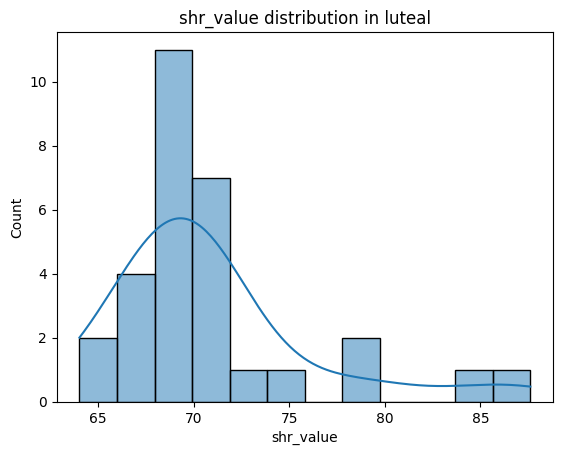

Shapiro-Wilk for shr_value in follicular: p = 0.0207


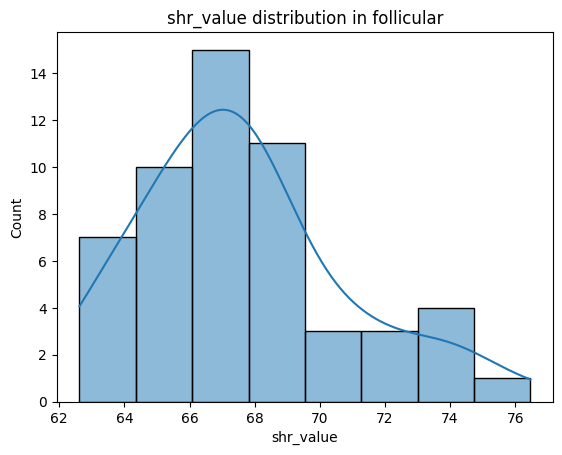

Shapiro-Wilk for shrv_value in luteal: p = 0.6369


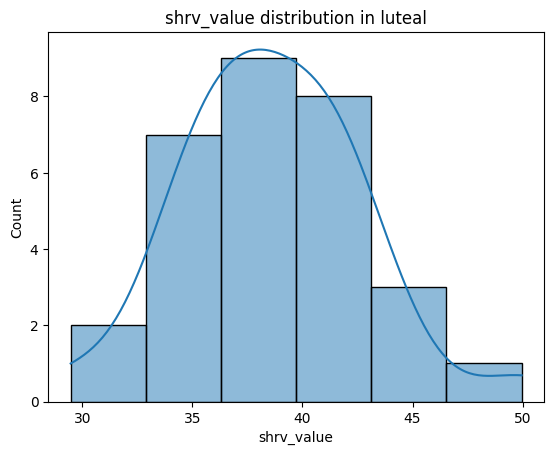

Shapiro-Wilk for shrv_value in follicular: p = 0.0046


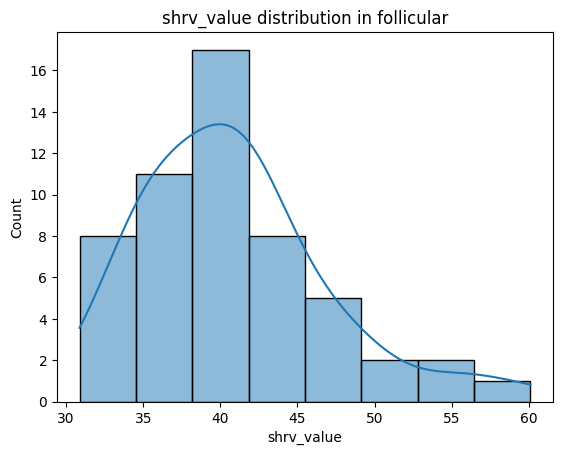

Shapiro-Wilk for temperature in luteal: p = 0.3646


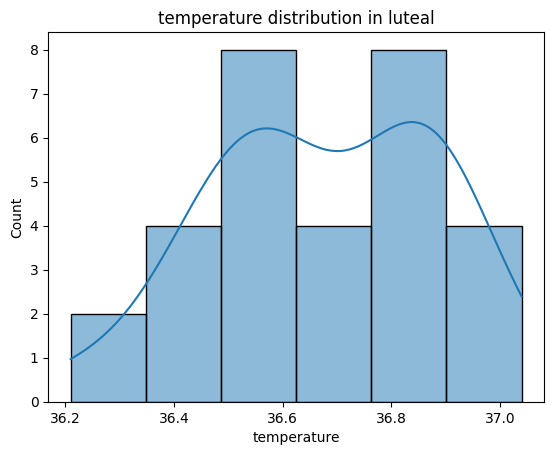

Shapiro-Wilk for temperature in follicular: p = 0.4340


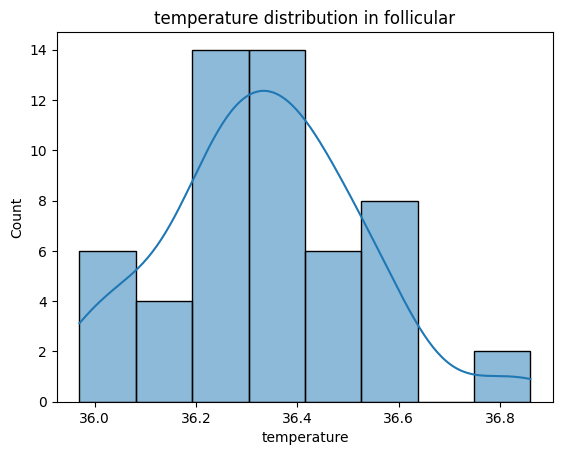

In [42]:
from scipy.stats import shapiro
import seaborn as sns
import matplotlib.pyplot as plt

untransformed_dvs = ["shr_value", "shrv_value", "temperature"]
dvs = ["bc_shr_value", "bc_shrv_value", "temperature"]

# Check Shapiro-Wilk for each DV within each phase
for var in untransformed_dvs:
    for phase in analysis_df["phase"].unique():
        stat, p = shapiro(analysis_df[analysis_df["phase"] == phase][var])
        print(f"Shapiro-Wilk for {var} in {phase}: p = {p:.4f}")

        # Optional: Q-Q plot
        sns.histplot(analysis_df[analysis_df["phase"] == phase][var], kde=True)
        plt.title(f"{var} distribution in {phase}")
        plt.show()


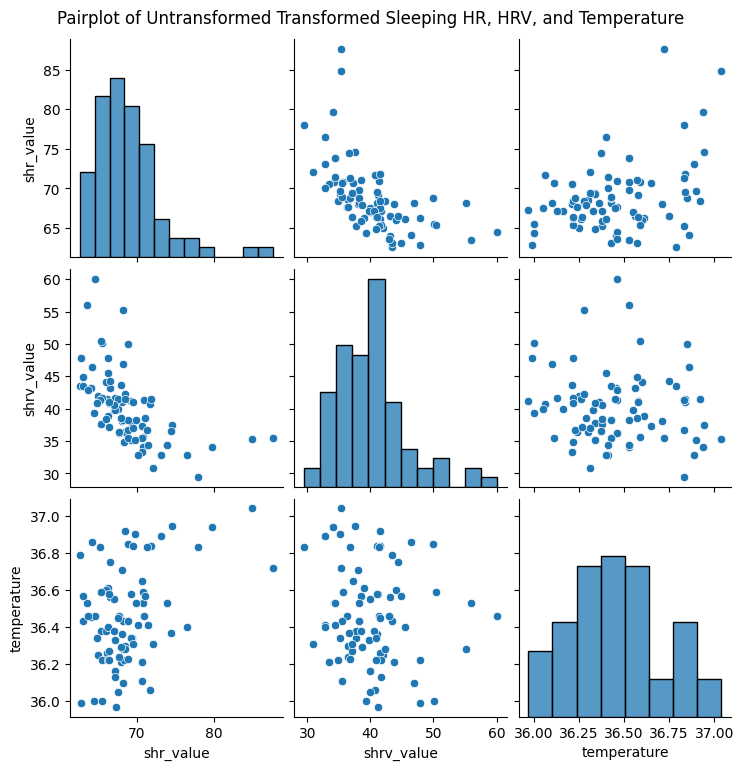

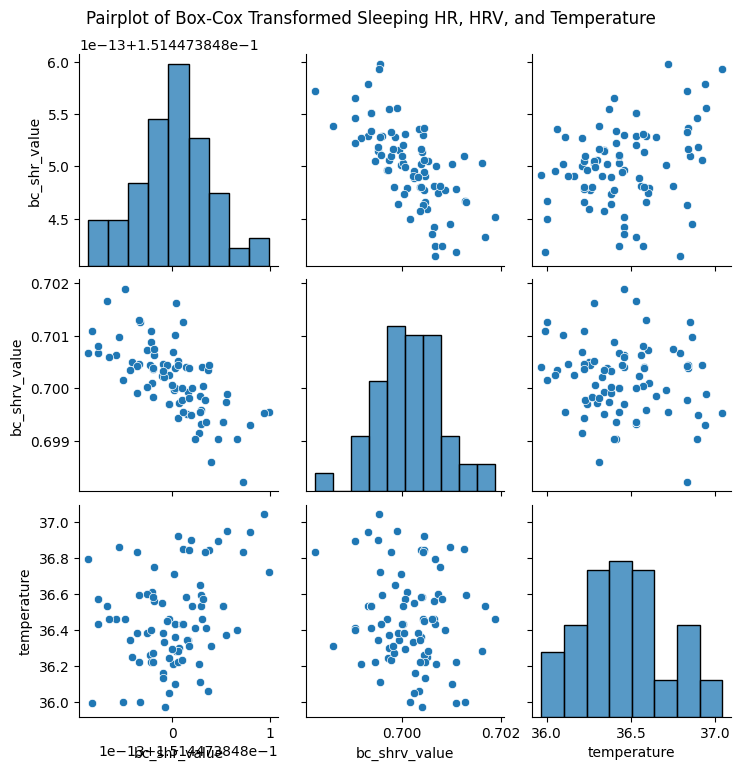

In [43]:
from scipy.stats import boxcox
import seaborn as sns
import matplotlib.pyplot as plt

# MAN(C)OVA assumes normality, so transformation is needed
# Box-Cox Transformation (because values are strictly positive)
analysis_df['bc_shr_value'], _ = boxcox(analysis_df['shr_value'])
analysis_df['bc_shrv_value'], _ = boxcox(analysis_df['shrv_value'])

# Visualize untransformed and transformed data
plot = sns.pairplot(analysis_df[untransformed_dvs])
plot.figure.suptitle('Pairplot of Untransformed Transformed Sleeping HR, HRV, and Temperature', y=1.02)
plt.show()

plot = sns.pairplot(analysis_df[dvs])
plot.figure.suptitle('Pairplot of Box-Cox Transformed Sleeping HR, HRV, and Temperature', y=1.02)
plt.show()


## 4.2 Homogeneity of Covariance Matrices

Here, our p-value = 0.22863 > 0.05, so we're in the clear.

In [39]:
from pingouin import box_m

# Perform Box's M test for homogeneity of covariance matrices
result = box_m(data=analysis_df, dvs=dvs, group="phase")
print("Box's M on Transformed Data:")
print(result)

Box's M on Transformed Data:
         Chi2   df     pval  equal_cov
box  8.131456  6.0  0.22863       True


## 4.3 Linearity

The results of the scatterplots below are slightly questionable; they do not seem to be linear, especially for the follicular phase.

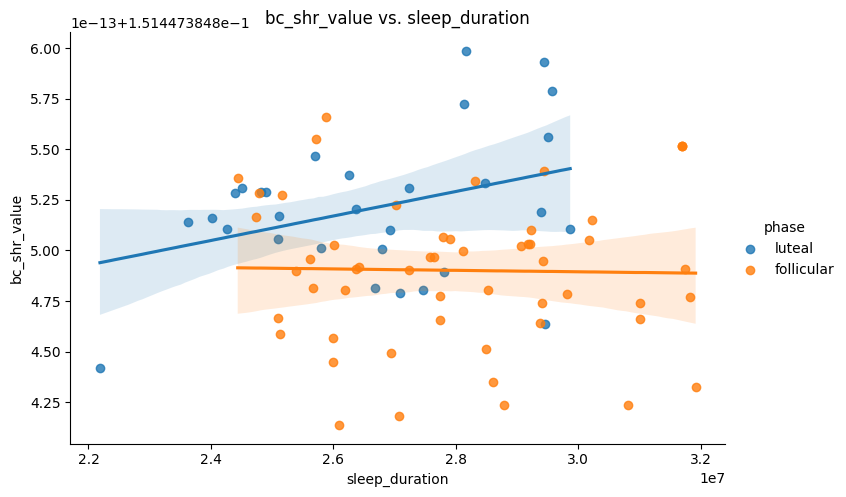

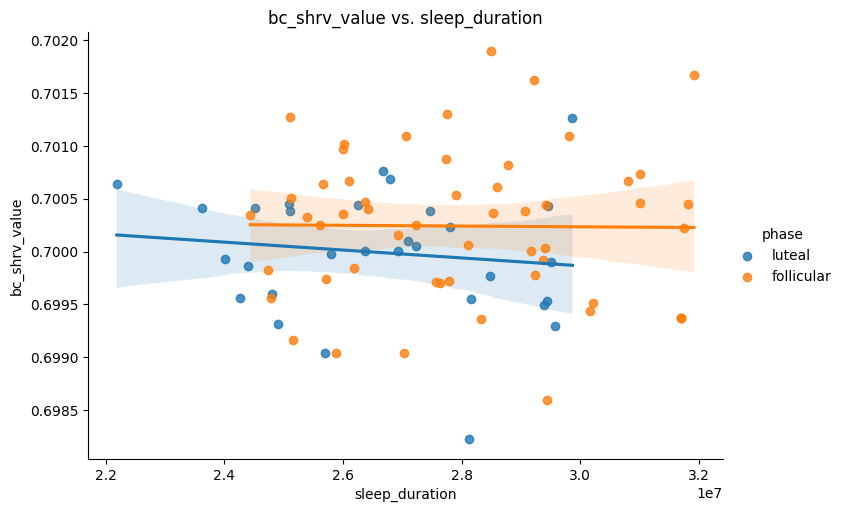

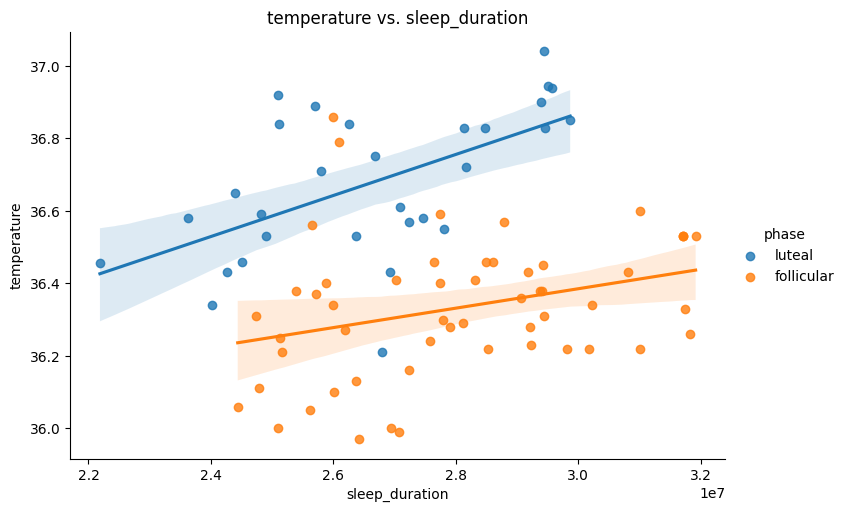

In [41]:
import seaborn as sns

for dv in dvs:
    sns.lmplot(data=analysis_df, x="sleep_duration", y=dv, hue="phase", aspect=1.5)
    plt.title(f"{dv} vs. sleep_duration")
    plt.show()


## 4.4 Checking for Multicollinearity

None of our correlations between DVs are higher than 0.8 (nor lower than -0.8), so we safely meet this assumption.

In [ ]:
# Check correlation between transformed variables
analysis_df[["bc_shr_value", "bc_shrv_value", "temperature"]].corr()

## 4.5. MANCOVA

In [ ]:
from statsmodels.multivariate.manova import MANOVA

# Run MANCOVA (Adding 'sleep_duration' as a covariate)
maov = MANOVA.from_formula('bc_shr_value + bc_shrv_value + temperature ~ phase + sleep_duration', data=analysis_df)
print(maov.mv_test())

                         Multivariate linear model
                                                                            
----------------------------------------------------------------------------
       Intercept            Value      Num DF  Den DF     F Value     Pr > F
----------------------------------------------------------------------------
          Wilks' lambda         0.0000 3.0000 79.0000 3560366430.3477 0.0000
         Pillai's trace         1.0000 3.0000 79.0000 3560366430.3477 0.0000
 Hotelling-Lawley trace 135203788.4942 3.0000 79.0000 3560366430.3477 0.0000
    Roy's greatest root 135203788.4942 3.0000 79.0000 3560366430.3477 0.0000
----------------------------------------------------------------------------
                                                                            
-------------------------------------------------------------------------------
             phase             Value     Num DF     Den DF    F Value    Pr > F
-------------------

## Interpretation

Here's a summary table by ChatGPT on the different test statistics:

| Test                   | Interpretation                                                                       | Statistic Range | Lower/Upper = ?          |
| ---------------------- | ------------------------------------------------------------------------------------ | --------------- | ------------------------ |
| Wilks' Lambda (Λ)      | Proportion of variance not explained by the IV(s). Smaller = better.                 | 0 to 1          | Lower = stronger effect  |
| Pillai’s Trace         | Proportion of explained variance. More robust to assumption violations.              | 0 to 1          | Higher = stronger effect |
| Hotelling-Lawley Trace | Sum of explained-to-unexplained variance ratios. Sensitive to assumption violations. | 0 to ∞          | Higher = stronger effect |
| Roy’s Greatest Root    | Focuses on the largest dimension of effect (not total). Sensitive to outliers.       | 0 to ∞          | Higher = stronger effect |

**p-values:** If p < 0.05, it suggests that phase significantly affects the dependent variables (HR, HRV, BBT), even after controlling for sleep duration.

> A multivariate analysis of covariance (MANCOVA) revealed a significant effect of menstrual phase on physiological outcomes, Wilks’ Λ = 0.53, F(2, 77) = 33.81, p < .001.
>
> This result was supported by Pillai’s Trace = 0.47, Hotelling’s Trace = 0.88, and Roy’s Root = 0.88, indicating that phase explained a substantial proportion of the variance in HR, HRV, and BBT.


## Follow-Up Analysis: One-Way ANCOVA For Each Variable

These one-way ANCOVAs show how much each DV contributes to phase—while still controlling for covariates (sleep duration).

In [45]:
import statsmodels.api as sm
from statsmodels.formula.api import ols


# One-way ANCOVA for HR
model_hr = ols("shr_value ~ phase + sleep_duration", data=analysis_df).fit()
anova_hr = sm.stats.anova_lm(model_hr, typ=2)
print("One-Way ANCOVA for Heart Rate:")
print(anova_hr)
print("\n")

# One-way ANCOVA for HRV
model_hrv = ols("shrv_value ~ phase + sleep_duration", data=analysis_df).fit()
anova_hrv = sm.stats.anova_lm(model_hrv, typ=2)
print("One-Way ANCOVA for Heart Rate Variability:")
print(anova_hrv)
print("\n")

# One-way ANCOVA for Temperature
model_temperature = ols("temperature ~ phase + sleep_duration", data=analysis_df).fit()
anova_temperature = sm.stats.anova_lm(model_temperature, typ=2)
print("One-Way ANCOVA for Basal Body Temperature:")
print(anova_temperature)
print("\n")

One-Way ANCOVA for Heart Rate:
                     sum_sq    df          F    PR(>F)
phase            254.734754   1.0  15.738895  0.000156
sleep_duration    40.656621   1.0   2.511987  0.116880
Residual        1310.988771  81.0        NaN       NaN


One-Way ANCOVA for Heart Rate Variability:
                     sum_sq    df         F    PR(>F)
phase             86.957143   1.0  2.923200  0.091143
sleep_duration     0.000563   1.0  0.000019  0.996539
Residual        2409.527144  81.0       NaN       NaN


One-Way ANCOVA for Basal Body Temperature:
                  sum_sq    df          F        PR(>F)
phase           2.765896   1.0  84.823123  3.055454e-14
sleep_duration  0.508789   1.0  15.603277  1.658862e-04
Residual        2.641232  81.0        NaN           NaN




We see that:
- **HR:** p < .05 — Menstrual phase significantly affects HR, controlling for covariates.
- **HRV:** p > .05 — No significant effect of phase on HRV when controlling for covariates.
- **BBT:** p < .01 — Strong evidence that temperature varies by phase.